# Forecasting & Opportunity Screen

Evaluates a held-out June portfolio forecast and connects forecast accuracy to commercial decision support. The model uses day-ahead price, gas price, calendar fields, and lagged generation; **real-time price is excluded to avoid target-time leakage**.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
forecast=pd.read_csv(ROOT/'data/processed/forecast_results.csv', parse_dates=['date'])
importance=pd.read_csv(ROOT/'data/processed/forecast_feature_importance.csv')

In [2]:
mape=forecast.ape.mean(); mae=forecast.abs_error_mwh.mean()
print(f'June MAPE: {mape:.2%}')
print(f'June MAE: {mae:,.0f} MWh/day')
importance

June MAPE: 11.85%
June MAE: 2,579 MWh/day


,feature,importance
0,avg_da_price,0.346008
1,dayofyear,0.163839
2,dow,0.158855
3,avg_gas_price,0.129366
4,lag1_generation,0.109996
5,lag7_generation,0.084408
6,month_num,0.007527


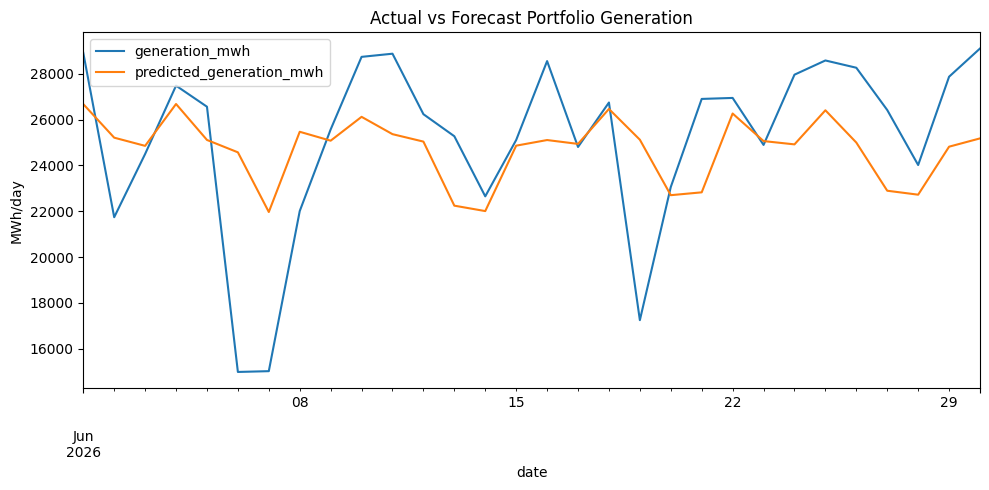

In [3]:
ax=forecast.plot(x='date', y=['generation_mwh','predicted_generation_mwh'], figsize=(10,5), title='Actual vs Forecast Portfolio Generation')
ax.set_ylabel('MWh/day'); plt.tight_layout(); plt.show()

## Next production step

For a real utility workflow, replace the synthetic inputs with weather forecasts, unit availability plans, market forward/day-ahead curves, outage schedules, and contract positions; then monitor forecast drift and residuals by technology and regime.